In [136]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from torch import nn, Tensor
from torch.utils.data import Dataset, DataLoader

In [9]:
df = pd.read_csv("../datasets/bbc_text_cls.csv")
df.head()

,text,labels
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


In [16]:
df["targets"] = df["labels"].astype("category").cat.codes

In [21]:
df_train, df_test = train_test_split(df, test_size = 0.3)

In [24]:
MAX_VOCAB_SIZE = 2_000
tokenizer = Tokenizer(num_words = MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(df_train["text"])

sequences_train = tokenizer.texts_to_sequences(df_train["text"])
sequences_test = tokenizer.texts_to_sequences(df_test["text"])

In [28]:
word2idx = tokenizer.word_index
print(f"Unique tokens: {len(word2idx)}")

Unique tokens: 27888


In [37]:
# Pad sequences so we have a useful matrix

data_train = pad_sequences(sequences_train)
print(f"Sequence length: {len(data_train[1])}")
print(data_train.shape)

Sequence length: 3479
(1557, 3479)


In [36]:
# Adjust test based on train
data_test = pad_sequences(sequences_test, maxlen = len(data_train[1]))
print(f"Sequence length: {len(data_test[1])}")

Sequence length: 3479


In [204]:
class TextClassification(nn.Module):
    def __init__(self, embedding_size: int, vocab_size: int, n_classes: int):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size + 1, embedding_size)

        self.conv = nn.Sequential(
            nn.Conv1d(embedding_size, 32, 3),
            nn.ReLU(inplace = True)
        )

        self.linear = nn.Sequential(
            nn.Linear(32 ,64),
            nn.Linear(64 ,n_classes)
        )
    
    def forward(self, x: Tensor):
        x = self.embedding(x)    # [batch, vocab_size, embedding_size]
        x = x.permute(0, 2, 1)   # [batch, embedding_size, vocab_size]
        x = self.conv(x)         # [batch, 32, vocab_size - 2]

        #Global max pooling
        x = torch.max(x, dim = 2)[0] # [batch, 32]
        x = self.linear(x)
        return x

class ClassficationDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype = torch.long)
        self.y = torch.tensor(y.to_numpy(), dtype = torch.long)  # shape: (N,)
    
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [205]:
e = 50
v = len(word2idx)
k = df["targets"].max() + 1

In [206]:
model = TextClassification(e, v, k)
criterion = nn.CrossEntropyLoss()
optim = torch.optim.Adam(model.parameters(), lr = 0.0025)

train_loader = DataLoader( ClassficationDataset(data_train, df_train["targets"]) , batch_size = 128)
test_loader = DataLoader( ClassficationDataset(data_test, df_test["targets"]) , batch_size = 1)

In [207]:
losses = []

model = model.to("cuda")
criterion = criterion.to("cuda")

for epoch in range(50):
    queue = tqdm(train_loader, total = len(train_loader))

    model.train()
    epoch_loss = 0
    for batch_idx, (x, y) in enumerate(queue):
        x = x.to("cuda")
        y = y.to("cuda")

        optim.zero_grad()

        output = model(x)
        loss = criterion(output, y)

        loss.backward()
        optim.step()

        epoch_loss += loss.item()
        losses.append(loss.item())
        
        queue.set_description(
            f"Epoch {epoch} | "
            f"Batch {batch_idx+1}/{len(train_loader)} | "
            f"Loss: {loss.item():.4f} | "
            f"Avg: {epoch_loss/(batch_idx+1):.4f}"
        )
    


  0%|          | 0/13 [00:00<?, ?it/s]

Epoch 0 | Batch 13/13 | Loss: 1.5254 | Avg: 1.6213: 100%|██████████| 13/13 [00:00<00:00, 58.23it/s]
Epoch 1 | Batch 13/13 | Loss: 1.2931 | Avg: 1.4748: 100%|██████████| 13/13 [00:00<00:00, 64.08it/s]
Epoch 2 | Batch 13/13 | Loss: 0.7770 | Avg: 1.1937: 100%|██████████| 13/13 [00:00<00:00, 64.97it/s]
Epoch 3 | Batch 13/13 | Loss: 0.3291 | Avg: 0.8019: 100%|██████████| 13/13 [00:00<00:00, 65.03it/s]
Epoch 4 | Batch 13/13 | Loss: 0.0937 | Avg: 0.4796: 100%|██████████| 13/13 [00:00<00:00, 65.15it/s]
Epoch 5 | Batch 13/13 | Loss: 0.0363 | Avg: 0.2950: 100%|██████████| 13/13 [00:00<00:00, 64.76it/s]
Epoch 6 | Batch 13/13 | Loss: 0.0191 | Avg: 0.1963: 100%|██████████| 13/13 [00:00<00:00, 64.69it/s]
Epoch 7 | Batch 13/13 | Loss: 0.0190 | Avg: 0.1487: 100%|██████████| 13/13 [00:00<00:00, 64.59it/s]
Epoch 8 | Batch 13/13 | Loss: 0.0130 | Avg: 0.1009: 100%|██████████| 13/13 [00:00<00:00, 64.36it/s]
Epoch 9 | Batch 13/13 | Loss: 0.0072 | Avg: 0.0769: 100%|██████████| 13/13 [00:00<00:00, 65.12it/s]


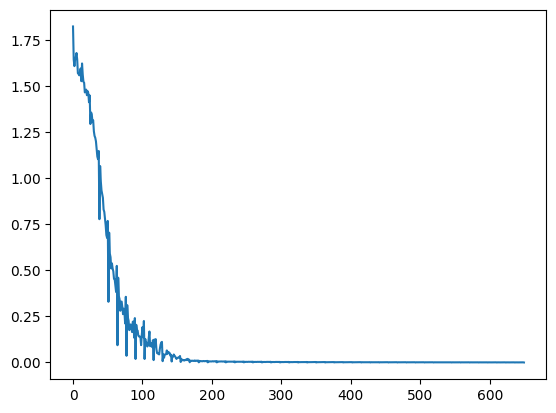

In [208]:
plt.plot(losses)
plt.show()

In [ ]:
queue = tqdm(test_loader, total = len(test_loader))
test_loss = 0

y_true = []
y_pred = []
y_pred_probs = []


model.eval()
with torch.no_grad():
    for batch_idx, (x, y) in enumerate(queue):
        x = x.to("cuda")
        y = y.to("cuda")

        optim.zero_grad()

        output = model(x)
        loss = criterion(output, y)

        y_true.append(y.cpu().numpy())
        y_pred.append(output.argmax().to("cpu"))
        y_pred_probs.append(torch.softmax(output, dim=1).cpu().numpy())

        test_loss += loss.item()
        queue.set_description(
            f"Epoch {epoch} | "
            f"Batch {batch_idx+1}/{len(test_loader)} | "
            f"Loss: {loss.item():.4f}"
        )

total_loss = test_loss / len(test_loader)
print(f"Test loss: {total_loss}")

Epoch 49 | Batch 668/668 | Loss: 0.0013: 100%|██████████| 668/668 [00:00<00:00, 1012.18it/s]

Test loss: 0.29951889844706053


In [227]:
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score

print(f"auc {roc_auc_score(y_true, y_preds, multi_class= "ovr" )}")
print(f"f1_score {f1_score(y_true, y_pred, average = None)}")

confusion_matrix(y_true, y_pred)

AxisError: axis 1 is out of bounds for array of dimension 1

In [221]:
y_preds

[tensor([[ 1.8680, -1.8852, -1.0934, -0.1293, -1.5806]]),
 tensor([[ 1.8309,  0.4869,  0.2135, -6.9137, -0.5527]]),
 tensor([[  0.1401, -10.6397,  13.3202,  -7.1926,  -4.0109]]),
 tensor([[-3.8818, -2.0197,  0.3308, -5.4415, 10.8835]]),
 tensor([[ 6.5131, -8.0811,  0.1723,  0.6611, -3.6587]]),
 tensor([[-1.0453, -5.9877, -0.6955, -5.2996, 13.8428]]),
 tensor([[ 2.3570, -4.5534,  6.9845, -7.1020, -3.6491]]),
 tensor([[-3.1200, -2.8383, -1.6851,  4.6946,  0.7954]]),
 tensor([[ 3.4674,  4.8665, -7.1001, -3.0753, -0.4000]]),
 tensor([[-2.0425, -2.7988,  0.7049, -6.0623,  9.5814]]),
 tensor([[-2.7863, -0.9063, -1.8672,  7.5560, -8.0854]]),
 tensor([[ 8.2764, -4.5243, -2.0406, -1.6677, -4.4912]]),
 tensor([[-6.3825, -1.7527, -1.3066,  8.4639, -0.6882]]),
 tensor([[-7.8504, 11.8417, -0.9151, -2.2092, -3.0920]]),
 tensor([[-3.6492,  8.1802, -3.0653, -3.1123, -2.4746]]),
 tensor([[ 1.4823, -8.4964, 11.0869, -9.6918, -1.8258]]),
 tensor([[-1.0425, -4.4871, -8.1717, 12.5774, -1.6164]]),
 tensor([